#  Customer Churn Prediction System using Deep Learning

---

##  1. Project Overview & Business Problem

In competitive industries such as Telecommunications, **customer retention** is critical to long-term profitability. Acquiring new customers can cost up to **5 to 25 times more** than retaining existing ones.

**Customer Churn** occurs when a customer cancels their subscription or stops doing business with a company. Predicting churn before it happens allows business teams to proactively offer incentives, customized deals, or improved support to retain high-value customers.

###  Business Objective
Build an end-to-end production-ready Deep Learning System using an **Artificial Neural Network (ANN)** to predict whether a telecommunications customer will churn (`Yes` / `No`) based on their demographic information, account details, and subscribed services.

---

##  2. Methodology & End-to-End Pipeline

To deliver a production-grade solution, the project is structured into 5 core phases:

1. **Exploratory Data Analysis (EDA) & Data Preprocessing:**
   * Clean missing/invalid values (e.g., coercing `TotalCharges`).
   * Encode categorical variables using One-Hot Encoding.
   * Feature Scaling using `StandardScaler` to ensure numerical stability for Gradient Descent.
   * Train / Validation / Test split.

2. **Model Architecture & Regularization:**
   * Multi-Layer Perceptron (ANN) built with TensorFlow / Keras.
   * Incorporating **L2 Regularization** and **Dropout Layers** to prevent Overfitting.
   * **Early Stopping Callbacks** to halt training when validation loss stops improving.

3. **Hyperparameter Tuning:**
   * Optimizing network architecture (layers, units, learning rate, activation functions) using **Keras Tuner**.

4. **Model Evaluation & Analysis:**
   * Evaluating performance using key classification metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
   * Confusion Matrix visualization.

5. **Deployment & Inference Pipeline:**
   * Saving model artifacts (`.h5` / `SavedModel`).
   * Creating a robust inference pipeline for predicting churn on new incoming customer profiles.

---

##  3. Dataset Summary
* **Source:** IBM Telco Customer Churn Dataset
* **Target Variable:** `Churn` (`Yes` / `No`)
* **Features:** Demographic metrics, Contract type, Payment method, Monthly/Total charges, and Subscribed utilities (Internet, Security, Streaming, etc.).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

In [4]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print("--- Sample Data ---")
display(df.head())

print("\n--- Data Info ---")
df.info()

--- Sample Data ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

#EDA

In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


/tmp/ipykernel_3793/2776066171.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='Set2')


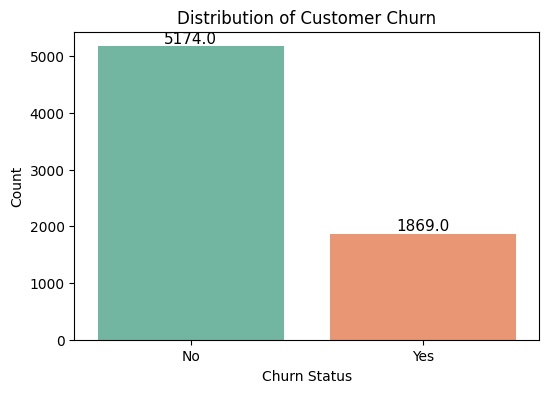

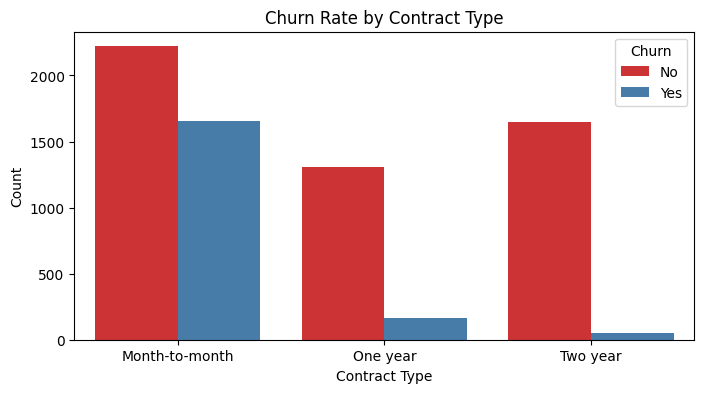

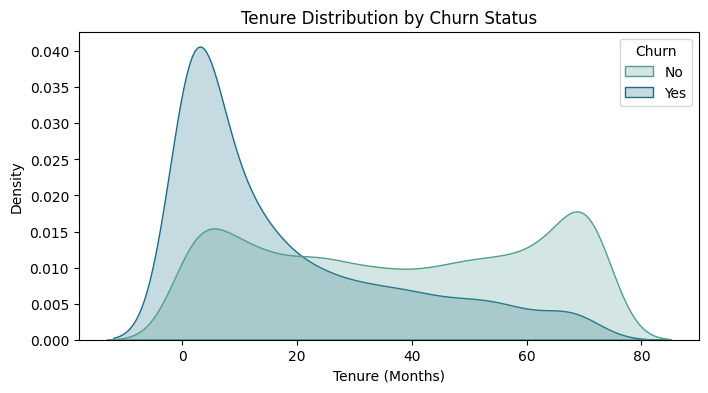

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()


plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.show()

####  Key Insight: Target Distribution (Class Imbalance)
* **Observed Pattern:** The target variable `Churn` shows a noticeable class imbalance, where the majority of customers belong to the non-churned class (~73%), while churned customers represent roughly ~27%.
* **Analytical Takeaway:** This imbalance indicates that accuracy alone will not be a reliable evaluation metric; precision, recall, and ROC-AUC must be prioritized during model evaluation.

####  Key Insight: Contract Type Impact
* **Observed Pattern:** Customers with **Month-to-month** contracts show a significantly higher churn rate compared to those on one-year or two-year contracts.
* **Analytical Takeaway:** Short-term contracts are the primary driver for customer loss. Incentivizing users to convert to long-term commitments can directly improve retention.

####  Key Insight: Tenure vs. Churn Behavior
* **Observed Pattern:** Churn is heavily concentrated among **new customers** (low tenure, typically under 6–12 months). As tenure increases, churn probability drops sharply.
* **Analytical Takeaway:** The first few months are critical for user onboarding; proactive retention strategies should target newly onboarded customers.

#Data Cleaning

In [9]:
# 1. Drop 'customerID' as it's a non-predictive unique identifier
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 2. Fix 'TotalCharges' column data type (convert blank spaces to NaN and handle them)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Impute missing values in 'TotalCharges' with the median
median_total = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total, inplace=True)

# 4. Encode binary target variable (Churn: No -> 0, Yes -> 1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(" Data cleaning complete!")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")
print("\nTarget Class Distribution:")
print(df['Churn'].value_counts())

 Data cleaning complete!
Remaining Missing Values: 0

Target Class Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_3793/2388835529.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total, inplace=True)


#Encoding, Scaling & Splitting

In [ ]:
# Use the already-cleaned 'df' from the Data Cleaning step above (no need to re-read/re-clean)
X = df.drop(columns=['Churn'])
y = df['Churn']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split FIRST (on raw, unscaled/unencoded data) to prevent data leakage.
# The preprocessor must never see validation/test data during fitting.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Fit the preprocessor ONLY on the training set, then use it to transform val/test.
# This avoids leaking any information (e.g. scaling statistics) from val/test into training.
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print("Preprocessing and data splitting completed successfully (no data leakage)!")
print(f"Training Set Size: {X_train.shape}")
print(f"Validation Set Size: {X_val.shape}")
print(f"Test Set Size: {X_test.shape}")

#ANN Architecture

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# تثبيت العشوائية لضمان تكرار النتائج
tf.random.set_seed(42)

input_dim = X_train.shape[1]

# 1. حساب أوزان الفئات لمعالجة عدم توازن البيانات
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

# 2. بناء هيكل الشبكة العصبية
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# 3. تجميع النموذج (تمت إضافة مقياس Recall هنا لمراقبته مباشرة)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')  # <-- إضافي لمتابعة الـ Recall أثناء التدريب
    ]
)

# 4. إعداد الـ Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_churn_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# 5. تدريب النموذج (تمت إضافة class_weight=class_weights هنا)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # <-- التعديل الأساسي والمهم جداً لرفع الـ Recall
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n Model training completed successfully! Best model saved as 'best_churn_model.h5'")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
144/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6155 - auc: 0.6745 - loss: 1.3228 - recall: 0.6599

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6860 - auc: 0.7651 - loss: 1.1331 - recall: 0.7148 - val_accuracy: 0.7036 - val_auc: 0.8355 - val_loss: 0.8978 - val_recall: 0.8464
Epoch 2/100
130/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - auc: 0.8355 - loss: 0.8063 - recall: 0.8098

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7424 - auc: 0.8216 - loss: 0.7696 - recall: 0.7844 - val_accuracy: 0.7235 - val_auc: 0.8394 - val_loss: 0.7171 - val_recall: 0.8429
Epoch 3/100
152/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7384 - auc: 0.8361 - loss: 0.6584 - recall: 0.8137

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7349 - auc: 0.8257 - loss: 0.6521 - recall: 0.7898 - val_accuracy: 0.7273 - val_auc: 0.8404 - val_loss: 0.6429 - val_recall: 0.8500
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7424 - auc: 0.8414 - loss: 0.5917 - recall: 0.8236

...

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7493 - auc: 0.8337 - loss: 0.5456 - recall: 0.7989 - val_accuracy: 0.7339 - val_auc: 0.8435 - val_loss: 0.5558 - val_recall: 0.8036
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7462 - auc: 0.8362 - loss: 0.5378 - recall: 0.7905 - val_accuracy: 0.7244 - val_auc: 0.8436 - val_loss: 0.5652 - val_recall: 0.8357
Epoch 9/100
145/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7499 - auc: 0.8441 - loss: 0.5260 - recall: 0.8177

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7475 - auc: 0.8330 - loss: 0.5383 - recall: 0.7913 - val_accuracy: 0.7320 - val_auc: 0.8442 - val_loss: 0.5515 - val_recall: 0.8214
Epoch 10/100
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7517 - auc: 0.8438 - loss: 0.5231 - recall: 0.8216

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7456 - auc: 0.8320 - loss: 0.5368 - recall: 0.7928 - val_accuracy: 0.7367 - val_auc: 0.8432 - val_loss: 0.5429 - val_recall: 0.8000
Epoch 11/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7485 - auc: 0.8307 - loss: 0.5371 - recall: 0.7882 - val_accuracy: 0.7320 - val_auc: 0.8435 - val_loss: 0.5497 - val_recall: 0.8179
Epoch 12/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7454 - auc: 0.8358 - loss: 0.5296 - recall: 0.7875 - val_accuracy: 0.7396 - val_auc: 0.8427 - val_loss: 0.5431 - val_recall: 0.8107
Epoch 13/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7483 - auc: 0.8357 - loss: 0.5276 - recall: 0.7836 - val_accuracy: 0.7348 - val_auc: 0.8440 - val_loss: 0.5445 - val_recall: 0.8286
Epoch 14/100
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7540 - auc: 0.8458 - loss: 0.5121 - recall: 0.8140

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7487 - auc: 0.8358 - loss: 0.5259 - recall: 0.7905 - val_accuracy: 0.7424 - val_auc: 0.8439 - val_loss: 0.5340 - val_recall: 0.8071
Epoch 15/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7525 - auc: 0.8371 - loss: 0.5245 - recall: 0.7951 - val_accuracy: 0.7424 - val_auc: 0.8449 - val_loss: 0.5349 - val_recall: 0.8143
Epoch 16/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7495 - auc: 0.8382 - loss: 0.5217 - recall: 0.7875 - val_accuracy: 0.7386 - val_auc: 0.8444 - val_loss: 0.5404 - val_recall: 0.8250
Epoch 17/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7497 - auc: 0.8331 - loss: 0.5281 - recall: 0.7898 - val_accuracy: 0.7367 - val_auc: 0.8441 - val_loss: 0.5432 - val_recall: 0.8250
Epoch 18/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7525 - auc: 0.8365 - loss: 0.5234 - recall: 0.7974 - val_accuracy: 0.7348 - val_auc: 0.8438 - val_loss: 0.5463 - val_recall: 0.8250
Epoch 19/100


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7458 - auc: 0.8345 - loss: 0.5261 - recall: 0.7844 - val_accuracy: 0.7434 - val_auc: 0.8443 - val_loss: 0.5305 - val_recall: 0.8036
Epoch 20/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7432 - auc: 0.8336 - loss: 0.5258 - recall: 0.7768 - val_accuracy: 0.7386 - val_auc: 0.8446 - val_loss: 0.5420 - val_recall: 0.8286
Epoch 21/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7501 - auc: 0.8338 - loss: 0.5254 - recall: 0.7905 - val_accuracy: 0.7386 - val_auc: 0.8436 - val_loss: 0.5406 - val_recall: 0.8286
Epoch 22/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7434 - auc: 0.8327 - loss: 0.5270 - recall: 0.7890 - val_accuracy: 0.7358 - val_auc: 0.8436 - val_loss: 0.5413 - val_recall: 0.8214
Epoch 23/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7505 - auc: 0.8352 - loss: 0.5233 - recall: 0.7905 - val_accuracy: 0.7339 - val_auc: 0.8450 - val_loss: 0.5456 - val_recall: 0.8321
Epoch 24/100


#Model Evaluation & Training Plots

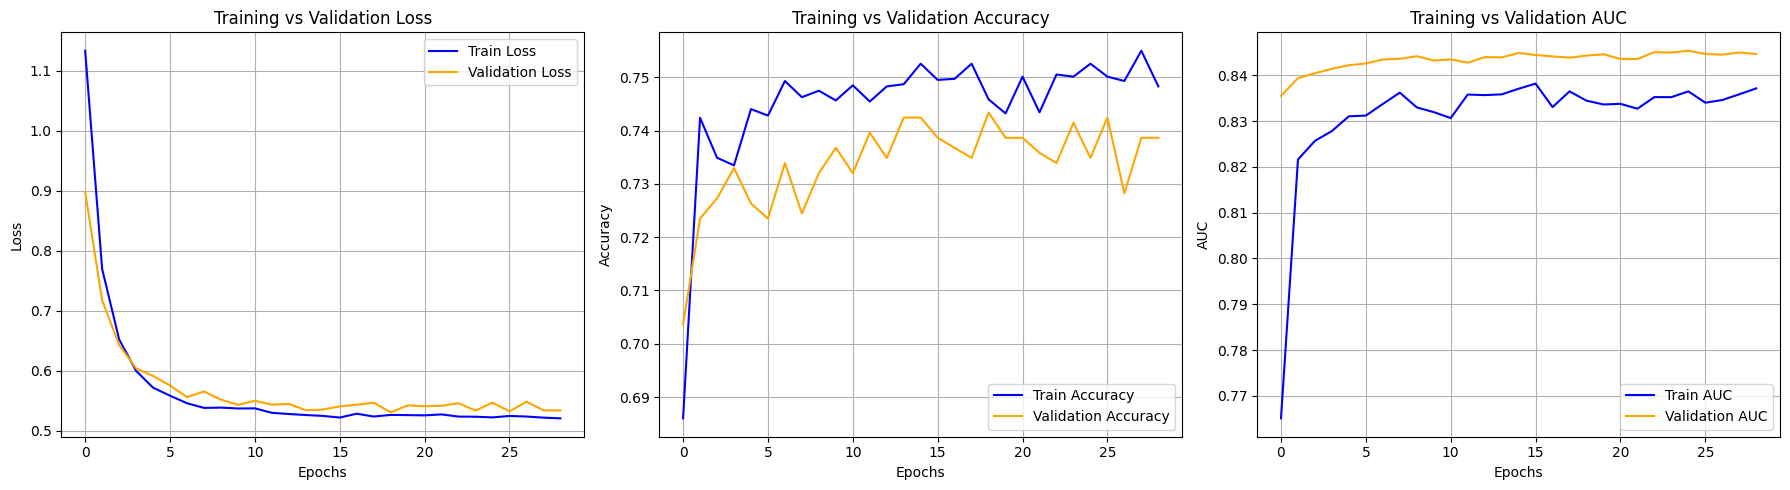

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
=== Classification Report on Test Set ===
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82       776
       Churn       0.54      0.78      0.63       281

    accuracy                           0.76      1057
   macro avg       0.72      0.77      0.73      1057
weighted avg       0.81      0.76      0.77      1057



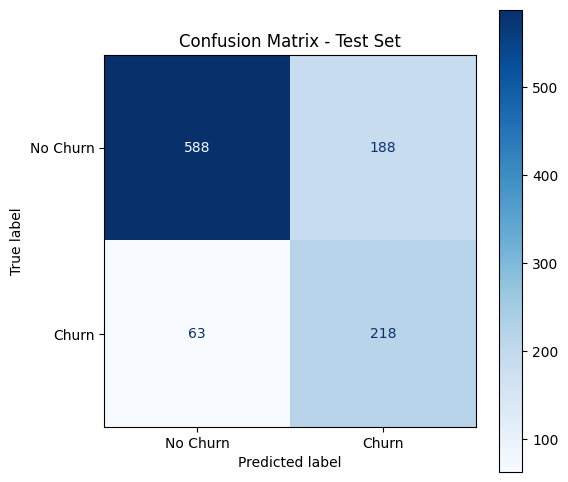

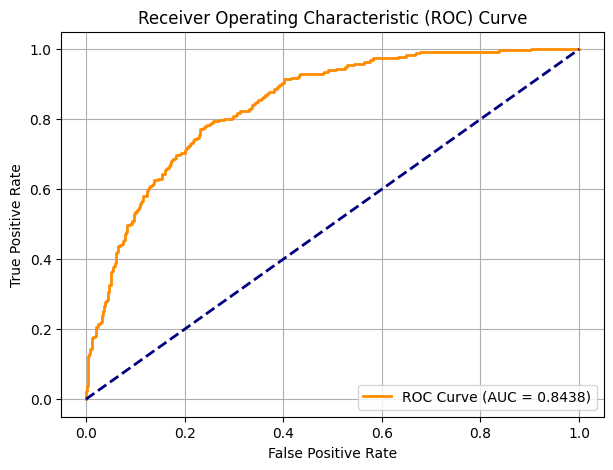

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['auc'], label='Train AUC', color='blue')
axes[2].plot(history.history['val_auc'], label='Validation AUC', color='orange')
axes[2].set_title('Training vs Validation AUC')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print("=== Classification Report on Test Set ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Test Set')
plt.show()

test_auc = roc_auc_score(y_test, y_pred_probs)
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Insight: Training & Validation Performance Analysis

---

* **1. Training vs Validation Loss:**
  * **Observation:** Both training and validation losses show a rapid and stable decrease from initial values, converging and stabilizing around `~0.52 - 0.54` after epoch 10.
  * **Insight:** The close alignment between the training and validation loss curves without any divergence indicates that the model successfully avoids **Overfitting**, confirming that regularization techniques are functioning effectively.

* **2. Training vs Validation Accuracy:**
  * **Observation:** Accuracy steadily increases and stabilizes at closely matched levels, with training accuracy reaching around `~75%` and validation accuracy holding near `~74%`.
  * **Insight:** The minimal gap between training and validation accuracy highlights strong **Generalization** capabilities, ensuring consistent predictive reliability on unseen data.

* **3. Training vs Validation AUC:**
  * **Observation:** The validation AUC score remains consistently high and stable, maintaining values between `0.84` and `0.845`.
  * **Insight:** The strong AUC score confirms the model's robust discriminative capability in distinguishing between churning and non-churning customers throughout the training process.

### Insight: Confusion Matrix Analysis (Test Set)

---

* **Matrix Breakdown:**
  * **True Negatives (TN = 588):** Non-churning customers correctly predicted as `No Churn`.
  * **False Positives (FP = 188):** Non-churning customers incorrectly predicted as `Churn`.
  * **False Negatives (FN = 63):** Actual churning customers missed by the model (predicted as `No Churn`).
  * **True Positives (TP = 218):** Actual churning customers correctly identified as `Churn`.

* **Key Performance Metrics:**
  * **High Recall for Churn (~77.6%):** Out of 281 actual churners ($218 + 63$), the model successfully identified **218** of them.
  * **Overall Accuracy (~76.2%):** Correctly classified **806** out of **1,057** total test samples.

* **Business Insight:**
  * **Minimizing High-Risk Errors (Low False Negatives):** Keeping False Negatives down to just **63** ensures that very few churning customers leave undetected.
  * **Trade-off Strategy:** The higher False Positive count (**188**) is an acceptable trade-off in customer retention, as sending a loyalty offer to a non-churning customer is significantly less costly than losing an actual customer completely.

### Insight: Receiver Operating Characteristic (ROC) Curve Analysis

---

* **Key Metric:**
  * **Area Under the Curve (AUC = 0.8438):** The model achieves a strong AUC score of **~84.4%**.

* **Observations:**
  * The orange curve rises steeply toward the top-left corner, remaining well above the diagonal dashed baseline ($AUC = 0.5$).

* **Insights & Interpretation:**
  * **Strong Discriminative Power:** An AUC of 0.8438 indicates an 84.4% probability that the model will correctly rank a randomly chosen churning customer higher than a non-churning customer.
  * **Threshold Tuning Flexibility:** The steep slope at lower False Positive Rates shows that the model can maintain high True Positive detection even when keeping false alarms low, allowing flexibility when choosing business decision thresholds.

In [14]:
!pip install keras-tuner
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
import keras_tuner as kt

def build_tunable_model(input_dim, learning_rate=0.001, units1=64, units2=32, dropout_rate=0.3):
    model = Sequential([
        Dense(units1, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
        Dropout(dropout_rate),
        Dense(units2, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = []

for lr in learning_rates:
    print(f"Training with learning rate = {lr}")
    m = build_tunable_model(X_train.shape[1], learning_rate=lr)
    h = m.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
    lr_results.append({'learning_rate': lr, 'val_accuracy': h.history['val_accuracy'][-1]})

lr_df = pd.DataFrame(lr_results)
lr_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.6 MB/s eta 0:00:00
Training with learning rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with learning rate = 0.01
Training with learning rate = 0.001
Training with learning rate = 0.0001


,learning_rate,val_accuracy
0,0.1000,0.757607
1,0.0100,0.777890
2,0.0010,0.786004
3,0.0001,0.786004


In [15]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_train), start=1):
    m = build_tunable_model(X_train.shape[1])
    m.fit(X_train[tr_idx], y_train.values[tr_idx], epochs=10, batch_size=32, verbose=0)
    _, acc = m.evaluate(X_train[val_idx], y_train.values[val_idx], verbose=0)
    fold_scores.append(acc)
    print(f"Fold {fold}: val accuracy = {acc:.4f}")

print(f"\nMean CV accuracy: {np.mean(fold_scores):.4f}  (+/- {np.std(fold_scores):.4f})")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: val accuracy = 0.8185
Fold 2: val accuracy = 0.8053
Fold 3: val accuracy = 0.7921
Fold 4: val accuracy = 0.7972
Fold 5: val accuracy = 0.8154

Mean CV accuracy: 0.8057  (+/- 0.0102)


In [16]:
def model_builder(hp):
    units1 = hp.Choice('units1', [32, 64, 128])
    units2 = hp.Choice('units2', [16, 32, 64])
    dropout_rate = hp.Choice('dropout_rate', [0.2, 0.3, 0.4])
    lr = hp.Choice('learning_rate', [0.01, 0.001, 0.0005])
    return build_tunable_model(X_train.shape[1], learning_rate=lr,
                                units1=units1, units2=units2, dropout_rate=dropout_rate)

tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='kt_search',
    project_name='churn_tuning',
    overwrite=True,
    seed=42
)

tuner.search(
    X_train, y_train, epochs=15, validation_split=0.2, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters found by Keras Tuner:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters found by Keras Tuner:
  units1: 64
  units2: 16
  dropout_rate: 0.2
  learning_rate: 0.001


In [ ]:
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight_dict)

final_model = build_tunable_model(
    X_train.shape[1],
    learning_rate=best_hp.values['learning_rate'],
    units1=best_hp.values['units1'],
    units2=best_hp.values['units2'],
    dropout_rate=best_hp.values['dropout_rate']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

final_history = final_model.fit(
    X_train, y_train,
    epochs=150, batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop_final],
    verbose=0
)

print(f"Training stopped at epoch {len(final_history.history['loss'])}")
final_model.save('final_churn_model.h5')
print("Final tuned model saved successfully as 'final_churn_model.h5'")

#Random Forest Baseline Comparison

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, y_pred_rf_probs)

print("=== Random Forest Baseline Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))
print(f"Random Forest Test AUC: {rf_auc:.4f}")
print(f"Neural Network Test AUC: {test_auc:.4f}")

=== Random Forest Baseline Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86       776
       Churn       0.64      0.49      0.55       281

    accuracy                           0.79      1057
   macro avg       0.74      0.69      0.71      1057
weighted avg       0.78      0.79      0.78      1057

Random Forest Test AUC: 0.8180
Neural Network Test AUC: 0.8438


#Model Deployment Preparation & Sample Inference

In [ ]:
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved successfully as 'preprocessor.pkl'")

def predict_customer_churn(customer_data, model_path='final_churn_model.h5', preprocessor_path='preprocessor.pkl'):
    loaded_model = tf.keras.models.load_model(model_path)
    loaded_preprocessor = joblib.load(preprocessor_path)

    df_customer = pd.DataFrame([customer_data])
    processed_data = loaded_preprocessor.transform(df_customer)

    churn_prob = loaded_model.predict(processed_data, verbose=0)[0][0]
    churn_pred = int(churn_prob > 0.5)

    return churn_prob, churn_pred

sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.70,
    'TotalCharges': 171.40
}

prob, pred = predict_customer_churn(sample_customer)

print("\n=== Sample Customer Prediction Result ===")
print(f"Churn Probability: {prob * 100:.2f}%")
print(f"Churn Risk Status: {'High Risk (Will Churn)' if pred == 1 else 'Low Risk (Retained)'}")